# Chapter 6: A Global Instrument
### *Modern Strain Gage Technology*, Companion Notebook

*Companion notebook to Chapter 6, A Global Instrument.*

The bonded resistance strain gage was conceived by Edward Simmons at Caltech in 1936 and, independently, by Arthur Ruge at MIT in 1938. Within about fifteen years it was being made, improved, and standardized in Britain, Germany, Japan, and the Soviet Union, and the decisive improvement of the period, the etched foil grid, came from Britain.

This notebook draws that spread as a chronology with one row per country, so that the reader can see at a glance what happened where, and in what order. Every event carries the source the chapter cites for it.

**This notebook demonstrates:**
1. A swim-lane timeline built from a small, auditable event table (year, country, label, source key).

In [1]:
# !pip install matplotlib
# (In Colab, uncomment the line above to install the single dependency.)

from pathlib import Path

import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Generated figures are written here; the book includes them from src/media/ch06/.
OUT_DIR = Path("../src/media/ch06")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1. The event table

Each row is one dated event: the year, the country where it happened, a short label, and the bibliography key of the source Chapter 6 cites for it. Keeping the sources in the table makes the figure easy to audit and to extend. The list is confined to the years in which the gage became international, 1936 to 1976; later milestones belong to later chapters.

Each label is placed by hand above or below its country's line, and centered on its leader or set off to one side of it, which keeps the labels in the crowded late 1930s and early 1950s from printing over one another.

In [2]:
# (year, country, label, side, alignment, source key in src/references.bib)
# side: +1 puts the label above the country's line, -1 below it.
# alignment: 'center', or 'right'/'left' to set a label off to one side of its
# leader where neighbouring events crowd together.
EVENTS = [
    (1936, "United States", "Simmons conceives\nbonded wire gage", +1, "right", "EandS1986Simmons"),
    (1938, "United States", "Ruge reaches it\nindependently", -1, "right", "EandS1986Simmons"),
    (1939, "United States", "SR-4 gages\non sale", +1, "left", "Keil2017"),
    (1943, "United States", "SESA Proceedings\nbegin", -1, "left", "SESAProc1943"),
    (1962, "United States", "Micro-Measurements\nfounded", +1, "center", "MM2020ShortHistory"),

    (1939, "Britain", "Tinsley lists strain\ngage bridges", +1, "right", "TinsleyHistory"),
    (1941, "Britain", "NPL makes gages\n(until 1958)", -1, "center", "JonesBSSM2024"),
    (1944, "Britain", "Gall (Tinsley):\nwire-gage patent", +1, "left", "JonesBSSM2024"),
    (1952, "Britain", "Jackson files\nfoil-gage patent", -1, "left", "JacksonGB720325"),
    (1964, "Britain", "BSSM\nformed", +1, "center", "JonesBSSM2024"),

    (1938, "Germany", "Czerlinsky (DVL):\nconstantan best", +1, "center", "Keil2017"),
    (1950, "Germany", "Hottinger\nfounded", -1, "center", "RadiomuseumHBM"),
    (1955, "Germany", "First German-made\ngages, Darmstadt", +1, "center", "Keil2017"),
    (1963, "Germany", "Renamed\nHBM", -1, "center", "RadiomuseumHBM"),

    (1949, "Japan", "Kyowa\nfounded", -1, "right", "KyowaHistory"),
    (1951, "Japan", "Kyowa K-1 on\nsale at ¥86", +1, "center", "JSME2024K1"),
    (1954, "Japan", "TML\nfounded", -1, "left", "TMLHistory"),
    (1961, "Japan", "TML exports to\nFrance, UK, US", +1, "left", "TMLHistory"),

    (1954, "Soviet Union", "TsAGI: wire gages\nfor dynamometers", +1, "center", "Nekhendzi1962"),
    (1962, "Soviet Union", "High-temperature\nconstantan gages", -1, "center", "Nekhendzi1962"),
    (1976, "Soviet Union", "GOST 21616-76\nstrain-gage standard", +1, "right", "GOST21616_91"),
]

COUNTRIES = ["United States", "Britain", "Germany", "Japan", "Soviet Union"]
# One marker shape per country, so the rows stay distinct in black-and-white print.
MARKERS = {"United States": "o", "Britain": "s", "Germany": "^", "Japan": "D", "Soviet Union": "v"}

for year, country, label, side, align, key in EVENTS:
    assert country in COUNTRIES and side in (-1, 1) and align in ("center", "left", "right"), (year, label)
print(f"{len(EVENTS)} events, {EVENTS[0][0]}-{max(e[0] for e in EVENTS)}")

21 events, 1936-1976


---
## 2. The chronology

Countries run top to bottom in the order the gage reached them in quantity. Each country has its own marker shape, and every label sits on a short leader above or below its row.

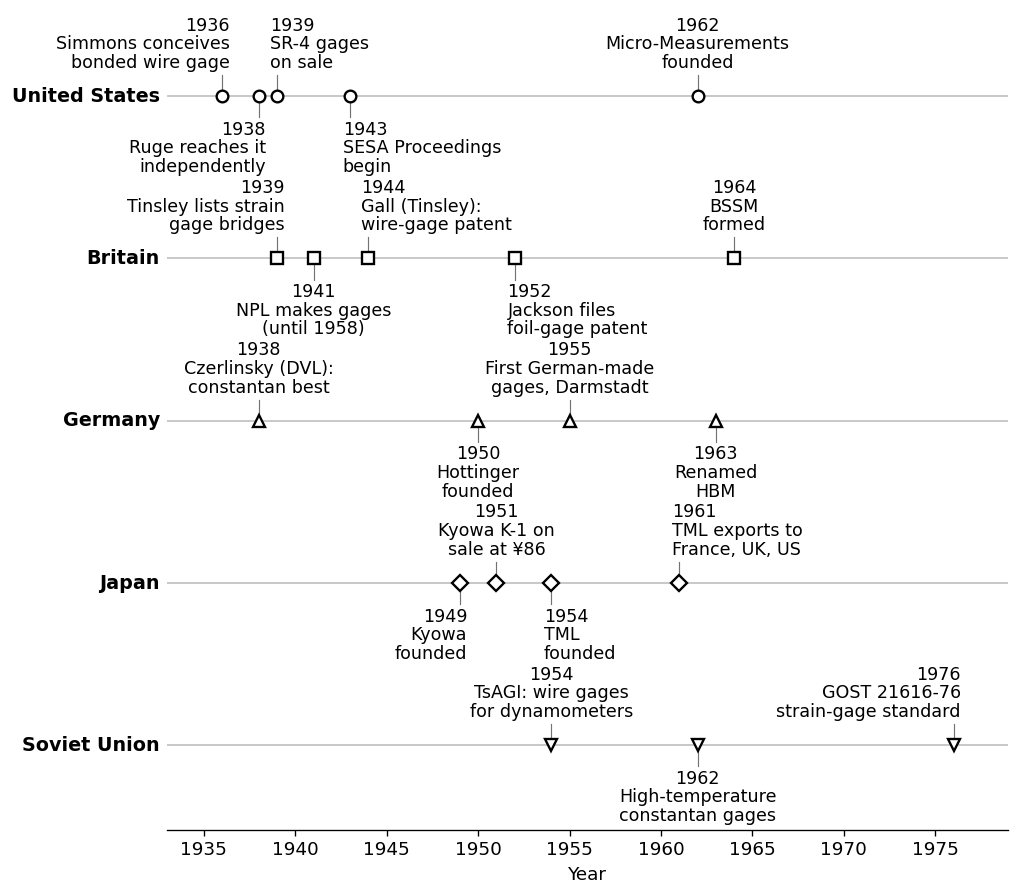

In [3]:
LANE_GAP = 1.0        # vertical distance between country rows (data units)
STEM = 0.13           # length of the leader from a marker to its label (data units)
LABEL_FONTSIZE = 10.5
SAVE_DPI = 300


def plot_chronology(events, out_path):
    fig, ax = plt.subplots(figsize=(8.6, 7.6))
    lane_y = {c: -i * LANE_GAP for i, c in enumerate(COUNTRIES)}

    for country, y in lane_y.items():
        ax.axhline(y, color='0.75', lw=1.0, zorder=1)
        ax.text(1932.6, y, country, ha='right', va='center', fontsize=11.5, fontweight='bold')

    for year, country, label, side, align, _key in events:
        y = lane_y[country]
        ax.plot(year, y, marker=MARKERS[country], ms=7, color='black',
                markerfacecolor='white', markeredgewidth=1.4, zorder=3, ls='none')
        ty = y + side * STEM
        ax.plot([year, year], [y, ty], color='0.45', lw=0.7, zorder=2)
        # A label set off to one side starts (or ends) a little past its leader.
        tx = year + {'center': 0.0, 'left': -0.4, 'right': 0.4}[align]
        ax.text(tx, ty + side * 0.02, f"{year}\n{label}", ha=align,
                va='bottom' if side > 0 else 'top', multialignment=align,
                fontsize=LABEL_FONTSIZE, linespacing=1.05, zorder=4)

    ax.set_xlim(1933, 1979)
    ax.set_ylim(-(len(COUNTRIES) - 1) * LANE_GAP - 0.52, 0.52)
    ax.set_yticks([])
    for side in ('left', 'right', 'top'):
        ax.spines[side].set_visible(False)
    ax.set_xticks(range(1935, 1980, 5))
    ax.tick_params(axis='x', labelsize=11)
    ax.set_xlabel('Year', fontsize=11)
    fig.tight_layout()
    fig.savefig(out_path, dpi=SAVE_DPI, bbox_inches='tight')
    return ax


plot_chronology(EVENTS, OUT_DIR / 'fig06_nb1_strain_gage_milestones.png')
plt.show()

---
## Where to take this next

- **Print the sources on the chart.** Turn the `key` column into superscript numbers on each label and print the key list beneath the figure, so the chart can stand on its own outside the book.
- **Add a country.** France (ONERA, founded 1946), Italy, Sweden, and Czechoslovakia all had strain-gage histories in these decades. Add rows only for events you can date from a source you have read.
- **Measure the lag.** For each country, compute the gap between 1939 (the first commercial SR-4 gages) and its first domestic production. The differences say something about licences, materials, and wartime isolation.